# 06 — Adaptive Query Execution (AQE) Deep Dive

**Concept:** AQE is Catalyst running *at runtime*, after each shuffle stage completes. Static Catalyst optimizes the plan once at plan time using catalog statistics or estimates. AQE re-optimizes the plan between stages using **ground-truth shuffle file sizes** — bypassing the guesswork that makes static optimization brittle on skewed or poorly-estimated data.

**Core interview question:** *"What are AQE's three features and when does each fire?"*

## What you will observe
1. **How to read AQE decisions** — `AdaptiveSparkPlan isFinalPlan=false` vs `isFinalPlan=true`, and the `AQEShuffleRead` node.
2. **Partition coalescing** — 200 planned shuffle partitions → N actual partitions based on real data volume.
3. **SMJ → BHJ conversion** — a pre-execution `SortMergeJoin` becomes a `BroadcastHashJoin` post-execution when AQE sees the build side is small.
4. **Skew join optimization** — oversized shuffle partitions split into sub-tasks so one slow task does not stall the whole stage.
5. **Dynamic Partition Pruning (DPP)** — fact-table partitions skipped at runtime based on the dimension-table filter result.

## AQE's position in Spark's optimization stack

```
Static plan (Catalyst)          Runtime re-optimization (AQE)     Execution (Tungsten)
──────────────────────          ─────────────────────────────     ────────────────────
Runs once at plan time.         Runs after each shuffle stage      Executes whatever
Input: logical plan             completes.                         plan exists, fast.
       + catalog statistics     Input: actual shuffle file sizes   Off-heap UnsafeRow,
Output: physical plan           Output: revised plan for the       codegen, cache-aware
        with operators chosen.  next stage.                        algorithms.
```

**Why AQE exists:** static Catalyst must guess partition count, join strategy, and data skew from statistics that are often absent or stale. A `groupBy` on 200 shuffle partitions where 198 are nearly empty wastes 198 tasks. A join where the build side fits in memory after a filter but not before. AQE fixes these at runtime, after the shuffle files are written and their sizes are known.

## The three AQE features

| Feature | When it fires | What it does |
|---|---|---|
| **Partition coalescing** | After any shuffle stage | Merges small shuffle partitions into fewer, larger ones — reducing task overhead |
| **SMJ → BHJ conversion** | After the build-side stage completes | Converts `SortMergeJoin` to `BroadcastHashJoin` if the actual build side is below the broadcast threshold |
| **Skew join optimization** | When a shuffle partition is much larger than the median | Splits the oversized partition into sub-partitions and processes them as parallel tasks |

**Key distinction from static Catalyst:**
- Catalyst uses *estimates*. Without `ANALYZE TABLE`, estimates are often wrong.
- AQE uses *actual shuffle file sizes*. These are always accurate — measured, not estimated.

**When AQE runs:** between stages — specifically, after `ShuffleMapTask` writes its output files and before the next stage reads them. Every `Exchange` node is a potential AQE intervention point.

In [1]:
import sys
import os
from pathlib import Path
import random

sys.path.append(str(Path().absolute().parent))

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")
os.environ["PATH"] = r"C:\hadoop\bin" + os.pathsep + os.environ.get("PATH", "")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType

warehouse_path = str(Path().absolute().parent / "data" / "warehouse")
os.makedirs(warehouse_path, exist_ok=True)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("06-aqe-deep-dive")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.minPartitionNum", "1")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.sql.cbo.enabled", "true")
    .config("spark.sql.warehouse.dir", warehouse_path)
    .config("spark.python.worker.reuse", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print(f"Spark {spark.version}  —  UI: http://localhost:4040")
print(f"AQE enabled             : {spark.conf.get('spark.sql.adaptive.enabled')}")
print(f"Partition coalescing    : {spark.conf.get('spark.sql.adaptive.coalescePartitions.enabled')}")
print(f"Skew join               : {spark.conf.get('spark.sql.adaptive.skewJoin.enabled')}")
print(f"autoBroadcast threshold : {spark.conf.get('spark.sql.autoBroadcastJoinThreshold')}")
print(f"shuffle.partitions      : {spark.conf.get('spark.sql.shuffle.partitions')}")

Spark 3.5.8  —  UI: http://localhost:4040
AQE enabled             : true
Partition coalescing    : true
Skew join               : true
autoBroadcast threshold : 10485760b
shuffle.partitions      : 200


In [2]:
random.seed(42)

products_schema = StructType([
    StructField("product_id",   IntegerType(), False),
    StructField("product_name", StringType(),  True),
    StructField("category",     StringType(),  True),
    StructField("price",        DoubleType(),  True),
    StructField("stock",        IntegerType(), True),
])
products_data = [
    (i, f"product_{i}", f"cat_{(i % 4) + 1}", round(random.uniform(5.0, 500.0), 2),
     random.randint(0, 1000))
    for i in range(1, 21)
]
products = spark.createDataFrame(products_data, schema=products_schema)

customers_schema = StructType([
    StructField("customer_id",   IntegerType(), False),
    StructField("customer_name", StringType(),  True),
    StructField("country_id",    IntegerType(), True),
])
customers = spark.createDataFrame(
    [(i, f"customer_{i}", (i % 5) + 1) for i in range(1, 201)],
    schema=customers_schema,
)

orders_schema = StructType([
    StructField("order_id",    IntegerType(), False),
    StructField("customer_id", IntegerType(), True),
    StructField("product_id",  IntegerType(), True),
    StructField("amount",      DoubleType(),  True),
])
orders_data = [
    (i, random.randint(1, 200), random.randint(1, 20), round(random.uniform(10.0, 2000.0), 2))
    for i in range(1, 10001)
]
orders = spark.createDataFrame(orders_data, schema=orders_schema)

# Write products to Parquet so AQE can measure shuffle file sizes for it
products_pq_path = Path().absolute().parent / "data" / "products_aqe"
products_pq_path.mkdir(parents=True, exist_ok=True)
products.toPandas().to_parquet(str(products_pq_path / "part-0.parquet"), index=False)
spark.sql("DROP TABLE IF EXISTS products_aqe")
spark.sql(f"CREATE TABLE products_aqe USING PARQUET LOCATION '{products_pq_path.as_uri()}'")
products_pq = spark.table("products_aqe")

print(f"products  : {products.count()} rows, {len(products.columns)} columns")
print(f"customers : {customers.count()} rows")
print(f"orders    : {orders.count()} rows")
print("products_aqe registered as Parquet table")

products  : 20 rows, 5 columns
customers : 200 rows
orders    : 10000 rows
products_aqe registered as Parquet table


## 1. Reading AQE decisions in `explain()`

AQE wraps the entire physical plan inside `AdaptiveSparkPlanExec`. The two states:

| State | When | What it means |
|---|---|---|
| `AdaptiveSparkPlan isFinalPlan=false` | Before any action runs | Preliminary plan — AQE may still rewrite it |
| `AdaptiveSparkPlan isFinalPlan=true` | After an action completes | Final executed plan — AQE decisions are baked in |

**Key nodes that appear only after execution:**

| Node | Meaning |
|---|---|
| `AQEShuffleRead` | Appears above `Exchange` after AQE coalesced the shuffle output |
| `BroadcastHashJoin` replacing `SortMergeJoin` | AQE converted the join strategy at runtime |

**The `explain(mode='codegen')` implication:**
Before execution, `isFinalPlan=false` hides the `WholeStageCodegen` subtrees inside the adaptive wrapper — `explain(mode='codegen')` reports "Found 0 WholeStageCodegen subtrees." After execution, `isFinalPlan=true` exposes the inner plan. Always run an action before calling `explain(mode='codegen')` when AQE is enabled, or temporarily disable AQE for pure plan inspection.

In [4]:
# Show isFinalPlan=false vs isFinalPlan=true on a simple aggregation
demo_query = (
    orders
    .groupBy("customer_id")
    .agg(F.sum("amount").alias("total_spend"))
)

print("PRE-EXECUTION — isFinalPlan=false:")
print("AQE wraps the plan; Exchange is planned but AQEShuffleRead not yet present")
print()
demo_query.explain(mode="formatted")

print("─" * 60)
print("Running collect() to let AQE finalize the plan...")
_ = demo_query.collect()
print()
print("POST-EXECUTION — isFinalPlan=true:")
print("AQE decisions visible — look for AQEShuffleRead above the Exchange")
print()
demo_query.explain(mode="formatted")

PRE-EXECUTION — isFinalPlan=false:
AQE wraps the plan; Exchange is planned but AQEShuffleRead not yet present

== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan ExistingRDD (1)


(1) Scan ExistingRDD
Output [4]: [order_id#16, customer_id#17, product_id#18, amount#19]
Arguments: [order_id#16, customer_id#17, product_id#18, amount#19], MapPartitionsRDD[14] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Project
Output [2]: [customer_id#17, amount#19]
Input [4]: [order_id#16, customer_id#17, product_id#18, amount#19]

(3) HashAggregate
Input [2]: [customer_id#17, amount#19]
Keys [1]: [customer_id#17]
Functions [1]: [partial_sum(amount#19)]
Aggregate Attributes [1]: [sum#69]
Results [2]: [customer_id#17, sum#70]

(4) Exchange
Input [2]: [customer_id#17, sum#70]
Arguments: hashpartitioning(customer_id#17, 200), ENSURE_REQUIREMENTS, [pl

### What to observe

**Pre-execution:**
- Outermost node: `AdaptiveSparkPlan isFinalPlan=false`
- Inside: `Exchange hashpartitioning(customer_id, N)` — N is the planned partition count
- No `AQEShuffleRead` — the shuffle has not run yet

**Post-execution:**
- Outermost node: `AdaptiveSparkPlan isFinalPlan=true`
- `AQEShuffleRead` appears above the `Exchange`, showing the actual coalesced partition count
- The plan now reflects what *actually happened*, not what Catalyst predicted

**Interview shorthand:** *"Always read `isFinalPlan=true` for the real plan. `isFinalPlan=false` is a prediction; `isFinalPlan=true` is the executed truth."*

## 2. Feature 1 — Partition coalescing

**The problem:** `spark.sql.shuffle.partitions` defaults to 200. After a shuffle on a small-to-medium dataset, most partitions are tiny or empty. Running 200 tasks when only 10 carry meaningful data wastes scheduler overhead and creates 200 small output files.

**What AQE does:** after the preceding shuffle stage writes its output files, AQE measures each partition's byte size. Consecutive partitions smaller than `spark.sql.adaptive.advisoryPartitionSizeInBytes` (default 64 MB) are merged. The number of tasks in the next stage is reduced accordingly.

**Configuration:**

| Config | Default | Purpose |
|---|---|---|
| `spark.sql.adaptive.coalescePartitions.enabled` | `true` | Enable/disable coalescing |
| `spark.sql.adaptive.advisoryPartitionSizeInBytes` | `64MB` | Target size per output partition after coalescing |
| `spark.sql.adaptive.coalescePartitions.minPartitionNum` | `1` | Minimum output partitions after coalescing |

**When it fires:** any query with a shuffle (`groupBy`, `join`, `distinct`, `repartition`). The most common AQE optimization — fires on almost every aggregation query.

In [5]:
# ── Feature 1: Partition coalescing ──────────────────────────────────────────
# Force 200 shuffle partitions to make the coalescing effect visible
spark.conf.set("spark.sql.shuffle.partitions", "200")

coalesce_query = (
    orders
    .groupBy("customer_id")
    .agg(F.sum("amount").alias("total_spend"))
)

print("shuffle.partitions = 200")
print()
print("PRE-EXECUTION — Exchange plans for 200 partitions:")
coalesce_query.explain(mode="formatted")

print("─" * 60)
_ = coalesce_query.collect()
print()
print("POST-EXECUTION — AQEShuffleRead shows actual coalesced count:")
coalesce_query.explain(mode="formatted")

shuffle.partitions = 200

PRE-EXECUTION — Exchange plans for 200 partitions:
== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan ExistingRDD (1)


(1) Scan ExistingRDD
Output [4]: [order_id#16, customer_id#17, product_id#18, amount#19]
Arguments: [order_id#16, customer_id#17, product_id#18, amount#19], MapPartitionsRDD[14] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0, ExistingRDD, UnknownPartitioning(0)

(2) Project
Output [2]: [customer_id#17, amount#19]
Input [4]: [order_id#16, customer_id#17, product_id#18, amount#19]

(3) HashAggregate
Input [2]: [customer_id#17, amount#19]
Keys [1]: [customer_id#17]
Functions [1]: [partial_sum(amount#19)]
Aggregate Attributes [1]: [sum#80]
Results [2]: [customer_id#17, sum#81]

(4) Exchange
Input [2]: [customer_id#17, sum#81]
Arguments: hashpartitioning(customer_id#17, 200), ENSURE_REQUIREMENTS, [plan_id=158]

(5) HashAggregate
Inpu

### What to observe

**Pre-execution:**
```
Exchange hashpartitioning(customer_id, 200)
```
Catalyst planned 200 shuffle output partitions.

**Post-execution:**
```
AQEShuffleRead
+- Exchange hashpartitioning(customer_id, 200)
```
`AQEShuffleRead` sits above the Exchange and shows the actual partition count after coalescing. With 10 000 orders spread across 200 customers, the shuffle output is tiny — AQE merges most of the 200 planned partitions into a much smaller number.

---

### Apparent contradiction: "1 coalesced partition" vs "8 tasks" in the Stages tab

When running locally on an 8-core machine you may see:
- `AQEShuffleRead` showing **1 coalesced partition**
- Stages tab showing **8 tasks ran**

These refer to **two separate stages** — they are not contradictory:

```
Stage 0  (pre-shuffle):   Scan → HashAggregate(Partial)
                          Tasks = 8
                          ← spark.default.parallelism = number of local cores = 8
                          This stage writes 200 shuffle "buckets" to disk.

                               ↓ Exchange (shuffle boundary) ↓
                               AQE observes: all 200 buckets are tiny

Stage 1  (post-shuffle):  AQEShuffleRead (1 coalesced partition) → HashAggregate(Final)
                          Tasks = 1
                          ← AQE merged all 200 planned partitions into 1
```

**Rule of thumb:**
- Pre-shuffle task count → controlled by **input partitions** / `spark.default.parallelism` (= cores in local mode)
- Post-shuffle task count → controlled by `spark.sql.shuffle.partitions` (200 here), then **reduced at runtime by AQE**

If you click into Stage 1 specifically in the Stages tab you will see it ran only 1 task. The "8 tasks" row belongs to Stage 0. The `AQEShuffleRead` node in the SQL plan is attached to Stage 1.

---

**Spark UI check:**
- SQL tab: `AQEShuffleRead` node — note the actual vs planned partition count
- Stages tab: Stage 0 has tasks ≈ number of cores; Stage 1 has tasks = coalesced partition count

**Production impact:** on a 50 GB dataset where 200 shuffle partitions produce 200 files on GCS/S3, coalescing to 15 reduces file count by 92% — fewer small files to read in downstream jobs, lower listing overhead, better Parquet row-group utilization.

## 3. Feature 2 — SMJ → BHJ conversion at runtime

**The problem:** static Catalyst can only choose `BroadcastHashJoin` if it knows one side is small *at plan time*. Without statistics, it defaults to `SortMergeJoin` — two shuffles, two sorts — even when one side turns out to be tiny.

**What AQE does:** after the build side's shuffle stage completes, AQE's `DynamicJoinSelection` rule checks whether the build side is small enough to broadcast. If yes, it rewrites the plan to `BroadcastHashJoin`, eliminating the probe-side sort and one shuffle.

**Config pattern for AQE-only conversion:**
```python
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")          # static: always plan SMJ
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "200m") # AQE: convert if < 200MB
```
After execution, the post-execution plan shows `BroadcastHashJoin` replacing `SortMergeJoin`.

**Why the automatic conversion does not fire on this toy dataset (Spark 3.5.8):**

`DynamicJoinSelection` checks `Sort.logicalLink.stats.sizeInBytes <= threshold`. `logicalLink` is a pointer from each physical plan node back to the logical plan node it was derived from, and it is set by the strategy layer (`SparkStrategy.apply`) when physical plan nodes are created from logical nodes.

The Sort nodes required for SortMergeJoin ordering are injected by `EnsureRequirements` — a separate physical rewrite rule that runs *after* the strategy layer. Those Sort nodes have **no corresponding logical node** so `logicalLink = None`, and `None.exists {...} = false` regardless of what threshold is configured.

In production workloads, the conversion **does** fire because real queries have filters, projections, or subqueries on the build side that do have logical nodes — giving the physical plan a `logicalLink` chain with usable stats. A flat `orders.join(products)` with no build-side filter hits the degenerate case.

**Demo strategy:** show SMJ and BHJ plans side-by-side. `F.broadcast()` produces the **identical plan** that AQE's `DynamicJoinSelection` emits — same `BroadcastExchange` node, same eliminated Sort and shuffle. The only difference is who decided and when.

In [3]:
# ── Feature 2: SMJ vs BHJ plan structure ─────────────────────────────────────
orders_pq_path = Path().absolute().parent / "data" / "orders_aqe"
orders_pq_path.mkdir(parents=True, exist_ok=True)
orders.toPandas().to_parquet(str(orders_pq_path / "part-0.parquet"), index=False)
spark.sql("DROP TABLE IF EXISTS orders_aqe")
spark.sql(f"CREATE TABLE orders_aqe USING PARQUET LOCATION '{orders_pq_path.as_uri()}'")
orders_pq = spark.table("orders_aqe")

# ── Plan A: SortMergeJoin ─────────────────────────────────────────────────────
# Disable all broadcast so Catalyst is forced to shuffle + sort both sides.
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "-1")

smj_query = (
    orders_pq
    .join(products_pq, "product_id")
    .groupBy("category")
    .agg(F.sum("amount").alias("total"))
)

print("═" * 60)
print("PLAN A — SortMergeJoin")
print("Both broadcast thresholds = -1. Catalyst shuffles + sorts both sides.")
print("═" * 60)
_ = smj_query.collect()
smj_query.explain(mode="formatted")

# ── Plan B: BroadcastHashJoin ─────────────────────────────────────────────────
# F.broadcast() is a static hint that tells Catalyst to broadcast products_pq
# without checking any threshold. The plan it produces is STRUCTURALLY IDENTICAL
# to what AQE's DynamicJoinSelection emits automatically when:
#   1. autoBroadcastJoinThreshold = -1    (so static Catalyst plans SMJ)
#   2. adaptive.autoBroadcastJoinThreshold > build-side size (so AQE converts at runtime)
#   3. Build side has a filter in the logical plan (so Sort.logicalLink is not None)
#
# In production, AQE fires automatically. On this flat toy join without a
# build-side filter, the Sort nodes injected by EnsureRequirements have
# logicalLink = None, so DynamicJoinSelection's size check always returns false.
# F.broadcast() bypasses that check and shows the exact target plan.

bhj_query = (
    orders_pq
    .join(F.broadcast(products_pq), "product_id") # force broadcast join by using the broadcast() hint
    .groupBy("category")
    .agg(F.sum("amount").alias("total"))
)

print("═" * 60)
print("PLAN B — BroadcastHashJoin")
print("Explicit broadcast() hint. Same plan AQE emits via DynamicJoinSelection.")
print("═" * 60)
_ = bhj_query.collect()
bhj_query.explain(mode="formatted")

# Reset
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024))
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "-1")

════════════════════════════════════════════════════════════
PLAN A — SortMergeJoin
Both broadcast thresholds = -1. Catalyst shuffles + sorts both sides.
════════════════════════════════════════════════════════════
== Physical Plan ==
AdaptiveSparkPlan (33)
+- == Final Plan ==
   * HashAggregate (21)
   +- AQEShuffleRead (20)
      +- ShuffleQueryStage (19), Statistics(sizeInBytes=128.0 B, rowCount=4)
         +- Exchange (18)
            +- * HashAggregate (17)
               +- * Project (16)
                  +- * SortMergeJoin Inner (15)
                     :- * Sort (7)
                     :  +- AQEShuffleRead (6)
                     :     +- ShuffleQueryStage (5), Statistics(sizeInBytes=234.4 KiB, rowCount=1.00E+4)
                     :        +- Exchange (4)
                     :           +- * Filter (3)
                     :              +- * ColumnarToRow (2)
                     :                 +- Scan parquet spark_catalog.default.orders_aqe (1)
                    

### What to observe

**Plan A — SortMergeJoin:**
```
SortMergeJoin [product_id]
:- Sort [product_id ASC]                            ← added by EnsureRequirements
:  +- Exchange hashpartitioning(product_id, 200)   ← orders shuffled
:     +- FileScan parquet orders_aqe
+- Sort [product_id ASC]                            ← added by EnsureRequirements
   +- Exchange hashpartitioning(product_id, 200)   ← products shuffled
      +- FileScan parquet products_aqe
```
Two Exchanges, two Sorts. Both sides are shuffled and sorted.

**Plan B — BroadcastHashJoin:**
```
BroadcastHashJoin [product_id], BuildRight
:- Exchange hashpartitioning(product_id, 200)
:  +- FileScan parquet orders_aqe
+- BroadcastExchange HashedRelationBroadcastMode
   +- FileScan parquet products_aqe
```
***No shuffle, No Sort nodes. Products is sent to all executors as a hash table. The larger dataset (probe side) partitions remain exactly where they reside on the worker nodes. They are sequentially read and probed against the cached hash table (build side)***

**Cost difference:**

| | SMJ | BHJ |
|---|---|---|
| Shuffles | 2 | **0** |
| Sorts | 2 | **0** |
| Memory per executor | Low | Must hold build side in memory |

---

### Why DynamicJoinSelection does not fire automatically on this dataset

`DynamicJoinSelection.canBroadcastBySize` checks `Sort.logicalLink.stats.sizeInBytes <= threshold`.

The Sort nodes in Plan A (marked "added by EnsureRequirements") are injected *after* the strategy layer by a physical rewrite rule. Physical nodes created this way have no corresponding logical plan node — their `logicalLink = None`. `None.exists { ... }` is always false, so the check never evaluates the threshold or the actual shuffle size.

**In production, DynamicJoinSelection DOES fire** when the build side has a filter in the logical plan, e.g.:
```python
products_pq.filter(F.col("category") == "electronics").join(orders_pq, "product_id")
```
Here the `Filter` node comes from the logical plan. The physical `Filter → Exchange → Sort` chain propagates `logicalLink` up through the Sort. `DynamicJoinSelection` sees `Sort.logicalLink = Some(logicalFilter)`, and `logicalFilter.stats.sizeInBytes` reflects the post-filter size — which may be tiny even if the full table is large.

**Config to use on a real workload where the build side is filtered:**
```python
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")           # force SMJ statically
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "200m") # AQE converts if < 200MB
spark.sql("ANALYZE TABLE your_dimension_table COMPUTE STATISTICS FOR ALL COLUMNS")
```

**Interview answer:** *"AQE's `DynamicJoinSelection` converts SMJ→BHJ by checking the build side's logical plan stats against `adaptive.autoBroadcastJoinThreshold`. The key condition is that the Sort node at the top of the build-side subtree must have its `logicalLink` set — which only happens when the Sort was generated from a logical plan node by the strategy layer, not injected by `EnsureRequirements`. In practice this means the build side needs a filter, projection, or subquery in the query so that the physical plan has a `logicalLink` chain with populated stats. The produced plan is identical to using `F.broadcast()` statically — `BroadcastExchange` on the build side, no Sort nodes, one fewer shuffle."*

## 4. Feature 3 — Skew join optimization

**The problem:** when joining on a column where one key appears in 90% of rows, one shuffle partition ends up much larger than the others. A single task must process all those rows while all other tasks finish quickly — the entire stage waits on one outlier task.

**What AQE does:** after the shuffle stage, AQE detects that a partition exceeds the skew threshold. It splits the oversized partition into multiple sub-partitions and processes them as parallel tasks. On the other join side, the matching partition is replicated for each sub-partition.

**Configuration:**

| Config | Default | Purpose |
|---|---|---|
| `spark.sql.adaptive.skewJoin.enabled` | `true` | Enable skew join optimization |
| `spark.sql.adaptive.skewJoin.skewedPartitionFactor` | `5.0` | Skewed if > factor × median partition size |
| `spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes` | `256MB` | Also must exceed this absolute byte size |

**Both conditions must be met.** For the demo we lower the threshold so our small dataset triggers it.

**Comparison with manual salting:**

| | AQE skew join | Manual salting |
|---|---|---|
| Code change required | No | Yes — add salt column, two-pass aggregation |
| Extra shuffle | No | Yes — salt requires an extra groupBy |
| Requires knowing hot keys upfront | No | Yes |
| Works for joins AND aggregations | Joins only | Both |
| Applies automatically | Yes | Manual tuning per query |

In [26]:
# Create skewed orders: product_id=1 gets 90% of all rows
random.seed(99)
skewed_orders_data = [
    (i,
     random.randint(1, 200),
     1 if random.random() < 0.9 else random.randint(2, 20),
     round(random.uniform(10.0, 2000.0), 2))
    for i in range(1, 10001)
]
skewed_orders = spark.createDataFrame(skewed_orders_data, schema=orders_schema)

# Write as Parquet so the shuffle file sizes are measurable by AQE
skewed_path = Path().absolute().parent / "data" / "orders_skewed"
skewed_path.mkdir(parents=True, exist_ok=True)
skewed_orders.toPandas().to_parquet(str(skewed_path / "part-0.parquet"), index=False)
spark.sql("DROP TABLE IF EXISTS orders_skewed")
spark.sql(f"CREATE TABLE orders_skewed USING PARQUET LOCATION '{skewed_path.as_uri()}'")
orders_skewed_t = spark.table("orders_skewed")

# Verify the skew
print("Top 5 product_id by order count — product_id=1 should dominate (~9000 rows):")
orders_skewed_t.groupBy("product_id").count().orderBy(F.col("count").desc()).show(5)

Top 5 product_id by order count — product_id=1 should dominate (~9000 rows):
+----------+-----+
|product_id|count|
+----------+-----+
|         1| 9018|
|        19|   75|
|         9|   68|
|        10|   60|
|        14|   59|
+----------+-----+
only showing top 5 rows



In [ ]:
# ── Feature 3: Skew join ──────────────────────────────────────────────────────
# Lower thresholds so our small dataset triggers the optimization
# (default 256MB would never fire on this toy data)
spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes", "2000b")
spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionFactor", "2")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")  # force SMJ to see skew handling
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionSize", "1b")  # kill the 1 MB floor to avoid coalescing the skewed partition away. defaults to 1 MB and is the actual floor. Since all of your orders data (123.8 KiB) fits inside that 1 MB target, everything collapses to 1 partition no matter what you set advisoryPartitionSizeInBytes to
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionNum", "20")   # force ≥ 20 partitions

skew_join = (
    orders_skewed_t.repartition(8)   # ← round-robin: 8 tasks each write to join shuffle
    .join(products_pq, "product_id")
    .groupBy("category")
    .agg(F.count("order_id").alias("order_count"), F.sum("amount").alias("total"))
)

print("Skew thresholds lowered for demo (threshold=2000 bytes, factor=2)")
print()
print("PRE-EXECUTION — SortMergeJoin, no skew handling yet:")
skew_join.explain(mode="formatted")

Skew thresholds lowered for demo (threshold=2000 bytes, factor=2)

PRE-EXECUTION — SortMergeJoin, no skew handling yet:
== Physical Plan ==
AdaptiveSparkPlan (15)
+- HashAggregate (14)
   +- Exchange (13)
      +- HashAggregate (12)
         +- Project (11)
            +- SortMergeJoin Inner (10)
               :- Sort (5)
               :  +- Exchange (4)
               :     +- Exchange (3)
               :        +- Filter (2)
               :           +- Scan parquet spark_catalog.default.orders_skewed (1)
               +- Sort (9)
                  +- Exchange (8)
                     +- Filter (7)
                        +- Scan parquet spark_catalog.default.products_aqe (6)


(1) Scan parquet spark_catalog.default.orders_skewed
Output [3]: [order_id#400, product_id#402, amount#403]
Batched: true
Location: InMemoryFileIndex [file:/c:/Users/krivg/spark-bq/data/orders_skewed]
PushedFilters: [IsNotNull(product_id)]
ReadSchema: struct<order_id:int,product_id:int,amount:double>

(2)

**Why it the skewed partitions might not fire — the root cause is in the Shuffle Write column on the map side.**

Skew join splits a skewed reduce partition by dividing up the map tasks that wrote into it. It does not split rows arbitrarily — it assigns ranges of mapper outputs to different reader tasks. Look at Stage 1 (the map stage): the orders table was written as a single Parquet file `(toPandas().to_parquet(...))`, so Stage 1 ran with exactly 1 map task. That single map task wrote all 9,019 hot-key rows into one shuffle bucket. With only 1 map output to read from, there is nothing to divide — you cannot split a partition that has a single contributor.

**How to actually trigger the skew split?**

Force the source data to be read by multiple map tasks before the join shuffle. We can simulate this by applying a repartition to the orders table before the join: `orders_skewed_t.repartition(8)`. With 8 map tasks, each contributing ~1,125 rows to the hot-key bucket, AQE can assign mapper ranges to separate reader tasks: task A reads map outputs 0–3, task B reads map outputs 4–7. That produces 2 parallel tasks each processing ~4,500 rows instead of 1 task with 9,019 — and skew join actually fires.

In [28]:
_ = skew_join.collect()
print()
print("POST-EXECUTION — AQE detected and split the skewed partition:")
skew_join.explain(mode="formatted")

# Reset
spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes", str(256 * 1024 * 1024))
spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionFactor", "5")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024))
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionSize", "1mb")
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionNum", "1")   # force ≥ 20 partitions




POST-EXECUTION — AQE detected and split the skewed partition:
== Physical Plan ==
AdaptiveSparkPlan (36)
+- == Final Plan ==
   * HashAggregate (23)
   +- AQEShuffleRead (22)
      +- ShuffleQueryStage (21), Statistics(sizeInBytes=640.0 B, rowCount=16)
         +- Exchange (20)
            +- * HashAggregate (19)
               +- * Project (18)
                  +- * SortMergeJoin(skew=true) Inner (17)
                     :- * Sort (9)
                     :  +- AQEShuffleRead (8)
                     :     +- ShuffleQueryStage (7), Statistics(sizeInBytes=312.5 KiB, rowCount=1.00E+4)
                     :        +- Exchange (6)
                     :           +- ShuffleQueryStage (5), Statistics(sizeInBytes=312.5 KiB, rowCount=1.00E+4)
                     :              +- Exchange (4)
                     :                 +- * Filter (3)
                     :                    +- * ColumnarToRow (2)
                     :                       +- Scan parquet spark_catalog.de

### What to observe

**Pre-execution plan:**
- `SortMergeJoin` with two Exchanges on the orders side: one `RoundRobinPartitioning(8)` from `.repartition(8)`, one `hashpartitioning(product_id, 200)` for the join
- No skew indication — Catalyst cannot see key distribution at plan time

**Post-execution plan — the two signals that AQE fired:**

```
SortMergeJoin(skew=true)                          ← join node carries the skew=true flag
:- AQEShuffleRead  Arguments: coalesced and skewed ← orders side: both features ran
+- AQEShuffleRead  Arguments: coalesced            ← products side: only coalescing
```

The `Arguments` field on `AQEShuffleRead` tells you exactly which AQE rules touched each branch.

---

### AQEShuffleRead UI metrics — reading every number

**Orders side** (the skewed branch):

| Metric | Value | Meaning |
|---|---|---|
| `number of partitions` | 9 | Total `PartitionSpec` entries = actual tasks that run |
| `number of coalesced partitions` | 5 | 5 `CoalescedPartitionSpec` — normal buckets merged together |
| `number of skewed partitions` | 1 | 1 bucket detected as oversized (product_id=1) |
| `number of skewed partition splits` | 4 | That 1 bucket divided into 4 `PartialReducerPartitionSpec` sub-ranges |

`9 = 5 coalesced + 4 skew-splits` — these are the 200 planned Exchange partitions reduced to 9 actual tasks.

**Products side** (the replicated branch):

| Metric | Value | Meaning |
|---|---|---|
| `number of partitions` | 9 | Must match orders — join requires aligned partition counts |
| `number of coalesced partitions` | 5 | Same 5 `CoalescedPartitionSpec` as orders |
| (implied) 4 replicated | 4 | product_id=1 product row replicated once per skew-split task |

The products side has no `number of skewed partitions` metric because it is the non-skewed (build) side. Its 4 non-coalesced specs are replications, not further splits.

---

### How the 9 tasks break down

**Tasks 1–4** — the 4 skew-split sub-tasks (product_id=1):

| Task | Shuffle Read | Records |
|---|---|---|
| 1 | 25.6 KiB | 2,258 |
| 2 | 25.3 KiB | 2,241 |
| 3 | 25.7 KiB | 2,252 |
| 4 | 25.7 KiB | 2,271 |

Each reads from a different **mapper index range** of the 8 round-robin map tasks. The former single bottleneck (99.9 KiB / 9,019 rows) is now 4 parallel tasks of ~25 KiB / ~2,250 rows each.

Each writes **1 row** to the next shuffle — product_id=1 belongs to exactly 1 category, so each sub-task produces 1 partial aggregation row that the final stage merges.

**Tasks 0, 5–8** — the 5 coalesced normal tasks:

| Task | Records | Coverage |
|---|---|---|
| 0 | 42 | one group of merged small buckets |
| 5 | 244 | another merged group |
| 6 | 289 | another merged group |
| 7 | 214 | another merged group |
| 8 | 212 | another merged group |

---

### Before vs. after

```
BEFORE (1 map task — skew join cannot split):
  task-1  ████████████████████████████████████  99.9 KiB / 9,019 rows  ← stalls stage

AFTER (8 map tasks — 4-way split fires):
  task-1  ████████  25.6 KiB / 2,258 rows ┐
  task-2  ████████  25.3 KiB / 2,241 rows ├─ 4 parallel sub-tasks
  task-3  ████████  25.7 KiB / 2,252 rows ├─ each reads a mapper range
  task-4  ████████  25.7 KiB / 2,271 rows ┘
```

---

### Critical gotchas — two things that silently prevent skew join from firing

**1. Coalescing runs first and can swallow skew detection**

`CoalesceShufflePartitions` runs before `OptimizeSkewedJoin`. If coalescing collapses all 200 partitions to 1, the skew detector sees a single partition — a single partition cannot be `> factor × its own size` — and exits without firing.

The hidden culprit is `spark.sql.adaptive.coalescePartitions.minPartitionSize` (default **1 MB**). The effective target formula is:

```
targetSize = max(
    advisoryPartitionSizeInBytes,    # what you set
    max(
        minPartitionSize,            # 1 MB default — overrides advisory on small datasets
        ceil(totalBytes / minPartitionNum)
    )
)
```

Setting `advisoryPartitionSizeInBytes = 1b` alone still produces 1 partition because `minPartitionSize = 1 MB` dominates. The fix requires both:
```python
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionSize", "1b")  # remove the 1 MB floor
spark.conf.set("spark.sql.adaptive.coalescePartitions.minPartitionNum", "20")   # drive target via N
# → targetSize = ceil(totalBytes / 20)  ≈ 6 KB  → coalescing produces ~20 partitions, hot key stands alone
```

**2. Skew join splits by mapper index range — requires multiple map tasks**

Skew join does **not** redistribute rows. It divides the map output files that contributed to the skewed bucket and assigns different file ranges to different reader tasks. If only 1 map task wrote to that bucket, there is nothing to divide:

```
1 map task  → hot-key bucket: 1 mapper contribution → cannot split → skew join exits
8 map tasks → hot-key bucket: 8 mapper contributions → splits into sub-ranges → FIRES
```

The source data was written as a single Parquet file (`toPandas().to_parquet(...)`), so Spark reads it with 1 task. The fix is `.repartition(8)` **without a column** (round-robin) applied before the join inside the query plan:

```python
orders_skewed_t.repartition(8).join(products_pq, "product_id")
```

This inserts a `RoundRobinPartitioning(8)` Exchange. Stage N runs 8 tasks, each receiving ~1,250 rows with a mix of all product_ids. All 8 tasks then write into the join shuffle's hash buckets — the hot-key bucket receives contributions from all 8 mappers and can be split.

Do **not** use `repartition(8, "product_id")`: that hash-partitions by the join key, sending all product_id=1 rows to 1 of the 8 buckets. Only 1 task writes to the hot-key bucket → same failure.

---

**Interview answer:** *"AQE skew join fires after the shuffle stage when a partition exceeds both `skewedPartitionFactor × median` AND `skewedPartitionThresholdInBytes`. It splits by mapper index range — not by row count — so it requires multiple map tasks to have written into the skewed reduce partition. If only 1 map task contributed, there is nothing to sub-divide. On small datasets, coalescing runs first and can collapse all partitions to 1 before the skew detector runs; the fix is lowering `minPartitionSize` so coalescing leaves multiple partitions for the skew check. The split sub-tasks run in parallel; the matching partition from the other join side is replicated once per sub-task. In the plan: look for `SortMergeJoin(skew=true)` and `AQEShuffleRead Arguments: coalesced and skewed` on the skewed branch. Unlike manual salting, no code change is needed and hot keys need not be known upfront. Trade-off: skew join only handles joins — skewed aggregations still need salting."*

## 5. Dynamic Partition Pruning (DPP)

**The pattern:** a query joins a large partitioned fact table with a small dimension table, and filters on the dimension. Static partition pruning only works when the filter value is a literal known at plan time (e.g., `WHERE dt = '2024-01-01'`). DPP handles the case where the surviving key set is not known until the dimension scan runs.

**What DPP does:**
1. The dimension-side scan runs first (Stage 0).
2. Spark collects the set of join-key values that survived the dimension filter.
3. That set is injected as a `dynamicpruning` filter on the fact table's partition column.
4. The fact-table scan skips partitions whose partition key is not in the collected set — before reading any data from those partitions.

**Requirements for DPP to fire:**
- The fact table must be partitioned by the join key (or a column that maps to it)
- The join must be an equi-join on that key
- The dimension side must have a selective filter
- `spark.sql.optimizer.dynamicPartitionPruning.enabled = true` (default)

**In the plan:** `PartitionFilters` on the `FileScan` node contains `dynamicpruningexpression(...)`.

**Key difference from Catalyst predicate pushdown:**

| | Catalyst predicate pushdown | Dynamic Partition Pruning |
|---|---|---|
| **When** | Plan time | Runtime (after dimension scan) |
| **Input** | Static filter value | Dynamic set collected from dimension scan |
| **What is pruned** | Row groups inside a Parquet file | Entire fact-table directory partitions |
| **Requires partition column** | No | Yes — join key must match the partition column |

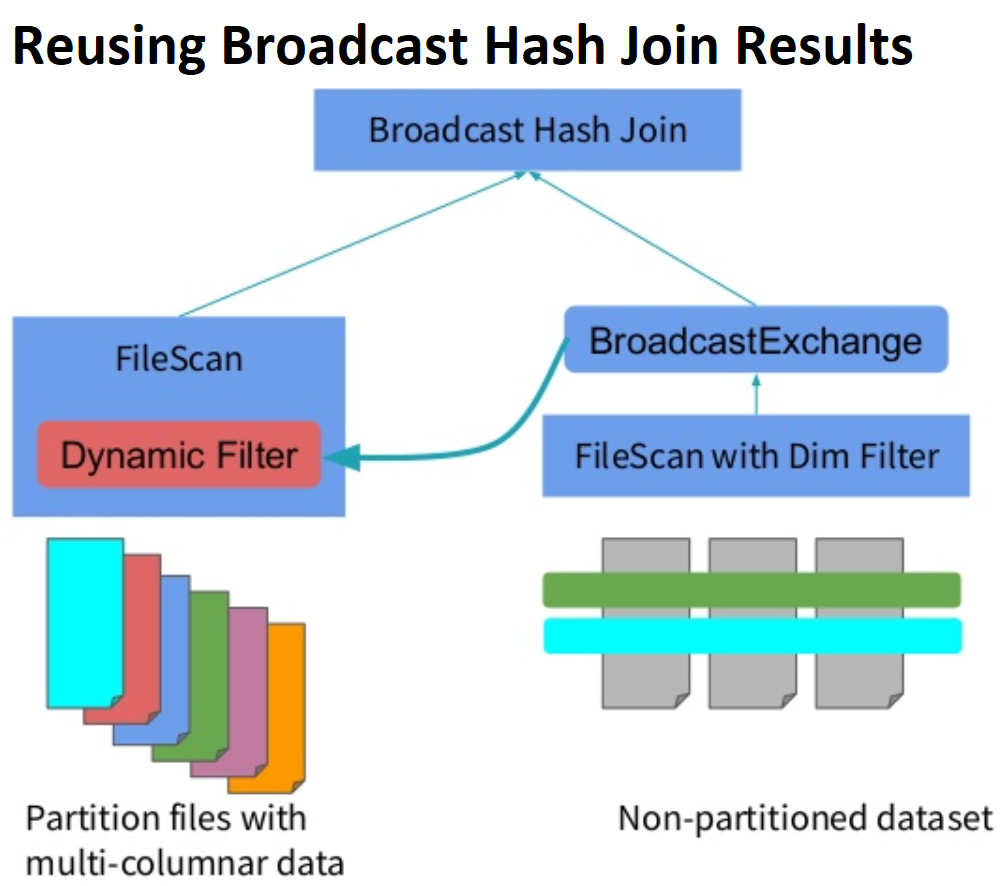

In [ ]:
# Write orders partitioned by product_id
# Partition column = product_id = join key → DPP condition satisfied
orders_partitioned_path = Path().absolute().parent / "data" / "orders_partitioned"

(
    orders
    .write
    .partitionBy("product_id") # To allow the DPP optimization to prune partitions, the fact table must be partitioned by the join key (product_id)
    .mode("overwrite")
    .parquet(str(orders_partitioned_path))
)

spark.sql("DROP TABLE IF EXISTS orders_fact")
spark.sql(f"""
    CREATE TABLE orders_fact
    USING PARQUET
    LOCATION '{orders_partitioned_path.as_uri()}'
""")
orders_fact = spark.table("orders_fact")

print(f"orders_fact: {orders_fact.count()} rows, partitioned by product_id (20 partitions)")
print()
print("Sanity check — FileScan should show PartitionFilters available:")
orders_fact.filter(F.col("product_id") == 1).explain(mode="formatted")

orders_fact: 0 rows, partitioned by product_id (20 partitions)

Sanity check — FileScan should show PartitionFilters available:
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet spark_catalog.default.orders_fact (1)


(1) Scan parquet spark_catalog.default.orders_fact
Output [4]: [order_id#125, customer_id#126, amount#127, product_id#128]
Batched: true
Location: InMemoryFileIndex []
PartitionFilters: [isnotnull(product_id#128), (product_id#128 = 1)]
ReadSchema: struct<order_id:int,customer_id:int,amount:double>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [order_id#125, customer_id#126, amount#127, product_id#128]




In [10]:
# ── DPP demo ──────────────────────────────────────────────────────────────────
# Filter dimension (products) to expensive items only.
# DPP should push the surviving product_ids back to prune fact-table partitions.
dpp_query = (
    orders_fact
    .join(
        products_pq.filter(F.col("price") > 300),   # filter on dimension
        "product_id"
    )
    .groupBy("category")
    .agg(F.sum("amount").alias("total"))
)

print("Query: orders_fact JOIN products WHERE price > 300")
print("Fact table partitioned by product_id — join key = partition key → DPP eligible")
print()
dpp_query.explain(mode="formatted")
print()
print("Look for: PartitionFilters containing 'dynamicpruningexpression' on the orders_fact FileScan node.")
print("That means Spark will only read the fact-table partitions whose product_id")
print("appears in the result of the products price > 300 filter.")

print()
_ = dpp_query.count()
print("POST-EXECUTION — AQE detected:")
dpp_query.explain(mode="formatted")

Query: orders_fact JOIN products WHERE price > 300
Fact table partitioned by product_id — join key = partition key → DPP eligible

== Physical Plan ==
AdaptiveSparkPlan (11)
+- HashAggregate (10)
   +- Exchange (9)
      +- HashAggregate (8)
         +- Project (7)
            +- BroadcastHashJoin Inner BuildLeft (6)
               :- BroadcastExchange (2)
               :  +- Scan parquet spark_catalog.default.orders_fact (1)
               +- Project (5)
                  +- Filter (4)
                     +- Scan parquet spark_catalog.default.products_aqe (3)


(1) Scan parquet spark_catalog.default.orders_fact
Output [2]: [amount#127, product_id#128]
Batched: true
Location: InMemoryFileIndex []
PartitionFilters: [isnotnull(product_id#128), dynamicpruningexpression(product_id#128 IN dynamicpruning#280)]
ReadSchema: struct<amount:double>

(2) BroadcastExchange
Input [2]: [amount#127, product_id#128]
Arguments: HashedRelationBroadcastMode(List(cast(input[1, int, true] as bigint)),fals

### What to observe

**In the FileScan node for `orders_fact`:**
```
PartitionFilters: [isnotnull(product_id), dynamicpruningexpression(product_id#... IN dynamicpruning#...)]
```
The `dynamicpruningexpression(...)` is the DPP filter. Spark runs a subquery that collects the surviving `product_id` values from the dimension side and uses them to prune the fact-table partitions before reading.

**What was saved:** products with `price > 300` represent roughly half the 20 products. Without DPP, all 20 fact-table partitions (directories) would be read. With DPP, only ~10 matching partitions are opened — the other directories are skipped at the file-system level before any data is deserialized.

**Spark UI check:**
- SQL tab: `FileScan` node for `orders_fact` → `Number of partitions read` should be less than 20
- SQL tab: there will be a separate subquery node in the plan representing the dimension-side collection

**When DPP does NOT fire:**
- Fact table is not partitioned, or join key ≠ partition column
- Dimension filter is not selective (all rows survive → Spark skips DPP as unprofitable)
- `spark.sql.optimizer.dynamicPartitionPruning.enabled = false`

## AQE configuration reference

| Config | Default | What it controls |
|---|---|---|
| `spark.sql.adaptive.enabled` | `true` | Master switch for AQE |
| `spark.sql.adaptive.coalescePartitions.enabled` | `true` | Enable partition coalescing |
| `spark.sql.adaptive.advisoryPartitionSizeInBytes` | `64MB` | Target partition size after coalescing |
| `spark.sql.adaptive.coalescePartitions.minPartitionNum` | `1` | Minimum partitions after coalescing |
| `spark.sql.adaptive.autoBroadcastJoinThreshold` | `-1` (inherits static) | Runtime SMJ→BHJ threshold; set independently to allow runtime-only conversion |
| `spark.sql.adaptive.skewJoin.enabled` | `true` | Enable skew join optimization |
| `spark.sql.adaptive.skewJoin.skewedPartitionFactor` | `5.0` | Partition is skewed if > factor × median |
| `spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes` | `256MB` | Partition is skewed if > this size AND > factor × median |
| `spark.sql.optimizer.dynamicPartitionPruning.enabled` | `true` | Enable DPP |

**Practical tip — enabling runtime-only SMJ→BHJ:**
```python
# Disable static broadcast detection (Catalyst cannot see the size at plan time)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

# Allow AQE to convert at runtime once it measures the actual shuffle file size
spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "10m")
```
This is the pattern that lets you observe the conversion in `explain()`: pre-execution shows SMJ, post-execution shows BHJ.

## When to disable AQE

AQE is on by default in Spark 3.x and is almost always beneficial. Cases where you might turn it off:

| Scenario | Why AQE causes a problem | Recommendation |
|---|---|---|
| **Plan debugging / `explain(mode='codegen')`** | `isFinalPlan=false` hides the `WholeStageCodegen` subtrees; codegen inspect shows 0 subtrees before execution | Disable temporarily for inspection; re-enable for production |
| **Deterministic plan tests** | AQE can produce different join strategies on repeated runs if data distribution changes, causing CI plan-equality assertions to fail | Use broadcast hints to pin strategies; compare only `isFinalPlan=true` plans |
| **Sub-second micro-batch streaming** | AQE's re-optimization overhead may exceed the optimization benefit for very short-lived jobs | Disable for streaming with < 1-second trigger intervals |
| **Join strategy regression investigation** | Need to see the static Catalyst plan to understand why a join was planned as SMJ | Disable temporarily, run `explain`, re-enable |

**How to disable selectively:**
```python
# SparkSession-level (affects all subsequent queries in this session)
spark.conf.set("spark.sql.adaptive.enabled", "false")
# ... do your plan inspection ...
spark.conf.set("spark.sql.adaptive.enabled", "true")   # always re-enable
```

## Spark UI checklist for AQE analysis

### SQL tab

**Step 1 — Identify the plan state**
- Find `AdaptiveSparkPlan` at the top of the plan
- `isFinalPlan=false` → pre-execution; do not read too much into this plan
- `isFinalPlan=true` → post-execution; this is the authoritative plan

**Step 2 — Verify partition coalescing**
- Find `AQEShuffleRead` in the post-execution plan
- Compare its reported partition count with the `N` in `Exchange hashpartitioning(col, N)`
- Large reduction = many small shuffle files were merged

**Step 3 — Check for SMJ → BHJ conversion**
- Pre-execution: `SortMergeJoin` with `Exchange` on both branches
- Post-execution: `BroadcastHashJoin` with `BroadcastExchange` on one branch = AQE converted it

**Step 4 — Verify skew join handling**
- Stages tab: the join stage has more tasks than shuffle partitions = sub-partitions were split
- Task duration histogram: the long-tail outlier task is gone

**Step 5 — Verify DPP**
- FileScan node for the fact table: `PartitionFilters` contains `dynamicpruningexpression(...)`
- `Number of partitions read` < total partitions = DPP skipped some directories

## Interview questions — answer from memory before moving on

### Q1. What are AQE's three main features? Give one example of each in a concrete query.

**A:**
1. **Partition coalescing:** a `SELECT customer_id, SUM(amount) FROM orders GROUP BY customer_id` with `spark.sql.shuffle.partitions=200` produces 200 planned partitions. On a 1 GB dataset, most are tiny. AQE merges them into ~15 tasks in the final aggregation stage.

2. **SMJ → BHJ conversion:** `orders.join(products, 'product_id')` without statistics — Catalyst plans SortMergeJoin because it does not know `products` is only 20 rows. After Stage 0 (products shuffle), AQE measures ~5 KB of shuffle files, sees it is below the broadcast threshold, and rewrites to BroadcastHashJoin.

3. **Skew join:** `orders.join(products, 'product_id')` where `product_id=1` appears in 90% of orders. After the shuffle, partition for `product_id=1` is 100× the median size. AQE splits it into sub-partitions and processes them in parallel tasks instead of one long-running task.

---

### Q2. How does AQE coalesce shuffle partitions? What triggers it and what is the result?

**A:**
After a shuffle stage writes its output files (ShuffleMapTasks complete), AQE reads the file size metadata for all partitions. Consecutive small partitions — those whose combined size is below `spark.sql.adaptive.advisoryPartitionSizeInBytes` (64 MB default) — are merged into one logical partition. The next stage spawns one task per merged partition instead of one per original partition.

**Result:** reduced task count, less scheduler overhead, fewer small output files. No data is rewritten — AQE reads contiguous small shuffle segments in a single task, it does not physically merge files.

---

### Q3. How does AQE convert SMJ to BHJ at runtime? Why can it do this when static Catalyst could not?

**A:**
AQE runs after the build side's shuffle stage completes. At that point, the shuffle files for the build side exist on disk and their sizes are known exactly. If the total build-side shuffle file size is below `spark.sql.adaptive.autoBroadcastJoinThreshold`, AQE rewrites the plan: the build side is broadcast from the driver to all executors, and a hash join replaces the sort-merge.

Static Catalyst cannot do this because it runs before any data is read — it would need **`ANALYZE TABLE`** statistics to know the build-side size, and those statistics are often absent or stale. AQE uses ground-truth file sizes, not estimates.

**Important config:** `spark.sql.adaptive.autoBroadcastJoinThreshold` defaults to `-1` (inheriting the static threshold). To allow AQE to convert while keeping static BHJ disabled, set the adaptive threshold independently: `spark.conf.set("spark.sql.adaptive.autoBroadcastJoinThreshold", "10m")`.

---

### Q4. What is AQE skew join optimization? How is it different from manual salting?

**A:**
AQE skew join detects, after the shuffle stage, that one or more partitions are much larger than the median (by default: > 5× median AND > 256 MB). It splits the oversized partition into sub-partitions and spawns multiple tasks to process them in parallel. The matching partition from the other side is replicated for each sub-partition.

**vs manual salting:**
- Salting requires code changes (add a salt column, two-pass aggregation or join), adds an extra shuffle, and requires knowing the hot keys in advance
- AQE skew join requires no code change, no extra shuffle, and works automatically at runtime regardless of which keys are hot
- Trade-off: AQE skew join only handles joins; skewed aggregations (`groupBy` with hot keys) still need manual salting

---

### Q5. What is Dynamic Partition Pruning? In what query pattern does it fire?

**A:**
DPP fires when: (1) a large fact table is partitioned by the join key, and (2) the query joins it with a filtered dimension table on that key.

Spark runs the dimension scan first, collects the set of join-key values that survived the filter, and injects that set as a `dynamicpruningexpression(...)` in the `PartitionFilters` of the fact-table scan. The fact-table scan then skips any partitions whose key is not in the collected set — before reading any data from those directories.

**Visible in the plan:** `PartitionFilters: [dynamicpruningexpression(product_id IN dynamicpruning#...)]` on the fact-table `FileScan` node.

**When it does not fire:** fact table is not partitioned by the join key; the dimension filter is not selective; `spark.sql.optimizer.dynamicPartitionPruning.enabled = false`.

---

### Q6. When would you disable AQE? What are the trade-offs?

**A:**
AQE is beneficial in the vast majority of cases. Disable it when:

1. **Debugging plans:** `isFinalPlan=false` wraps the plan and hides `WholeStageCodegen` subtrees from `explain(mode='codegen')`. Temporarily disable to inspect the static plan structure.

2. **Deterministic plan tests:** if a CI suite asserts on plan shape (join strategy, number of Exchange nodes), AQE may produce different plans on different runs depending on runtime data distribution. Pin strategies with broadcast hints instead.

3. **Very short-lived jobs:** for streaming micro-batch jobs with sub-second triggers, AQE's re-optimization overhead may outweigh the benefit.

**Trade-off of disabling:** you lose runtime partition coalescing (more tasks, more small files), runtime BHJ conversion (unnecessary shuffles and sorts on joins with small build sides), and automatic skew handling (one slow task can stall the entire join stage).

## Key takeaways — cheat sheet

**AQE in one sentence:** Catalyst running again after each shuffle stage, with actual shuffle file sizes instead of estimates.

**The three features:**
- **Coalesce:** small shuffle partitions → fewer tasks. Fires on every shuffle. Check `AQEShuffleRead` in the post-execution plan.
- **SMJ→BHJ:** build side smaller than threshold → broadcast join, no sort. Fires after build-side stage. Check for `BroadcastHashJoin` replacing `SortMergeJoin` in post-execution plan.
- **Skew join:** one partition >> median → split into sub-tasks. Fires when both factor AND byte threshold are exceeded. Check for extra tasks in the Stages tab.

**DPP:** not one of the three AQE features — it is a separate Catalyst rule, but it is runtime-dependent. Fires on star-schema joins where the fact table is partitioned by the join key. Check `dynamicpruningexpression(...)` in `PartitionFilters`.

**Reading plans with AQE:**
- `isFinalPlan=false` = prediction; `isFinalPlan=true` = ground truth
- `explain(mode='codegen')` shows 0 subtrees before execution when AQE is on
- Disable AQE temporarily for clean static plan inspection

**Key config to know:** `spark.sql.adaptive.autoBroadcastJoinThreshold` defaults to `-1` (inherits static). Set it independently to allow runtime-only SMJ→BHJ conversion.

**Next notebook:** `07_memory_model_and_spill.ipynb` — how executor JVM memory is divided, what causes disk spill, and how to diagnose GC pressure. Builds on this notebook because AQE's partition coalescing and skew handling directly affect how much execution memory each task needs.

In [ ]:
for tbl in ["products_aqe", "orders_aqe", "orders_skewed", "orders_fact"]:
    try:
        spark.sql(f"DROP TABLE IF EXISTS {tbl}")
        print(f"Dropped {tbl}")
    except Exception as e:
        print(f"Cleanup warning ({tbl}): {e}")

print()
print("Notebook complete. Spark UI still available at http://localhost:4040")
print("Run spark.stop() to shut down the session.")